# Product Analysis

This notebook analyzes product-level performance in the Superstore dataset.

The goal is to understand which products drive revenue and profit, and identify products that may be underperforming.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/superstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"])

## Top 10 Products by Sales

### Business Question

Which products generate the highest total sales?

In [31]:
top_products_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

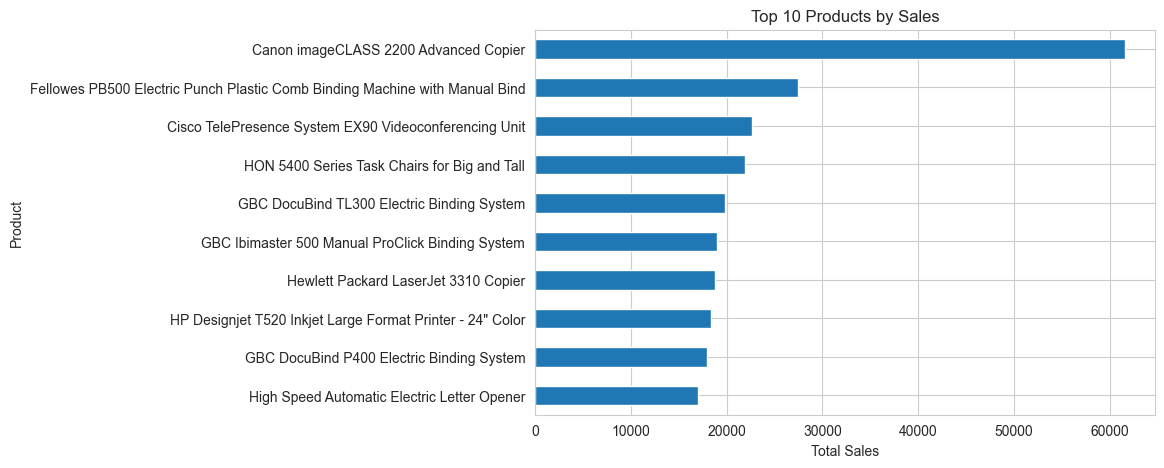

In [32]:
top_products_sales.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

### Insight

Sales are concentrated in a small number of products.

The Canon imageCLASS 2200 Advanced Copier generates substantially higher sales than the rest of the products in the top 10. The remaining products show a more gradual distribution, with several office equipment items such as binding machines, printers, and office chairs appearing among the highest-selling products.

## Top 10 Products by Profit

### Business Question

Which products generate the highest total profit?

In [33]:
top_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_profit

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

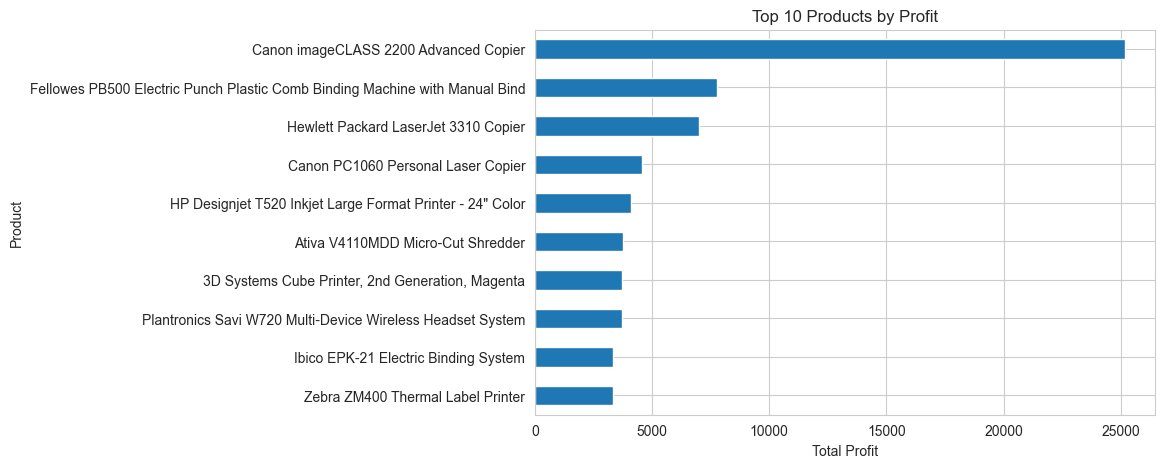

In [34]:
top_products_profit.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.show()

### Insight

Profit is concentrated in a small set of products.

The Canon imageCLASS 2200 Advanced Copier generates significantly more profit than any other product in the dataset. The remaining products produce noticeably lower profit levels, although several items that appeared among the top-selling products—such as the Fellowes PB500 Binding Machine and the HP LaserJet 3310 Copier—also appear among the most profitable products.

## Products Generating the Largest Losses

### Business Question

Which products generate the largest total losses?

In [35]:
worst_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

worst_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

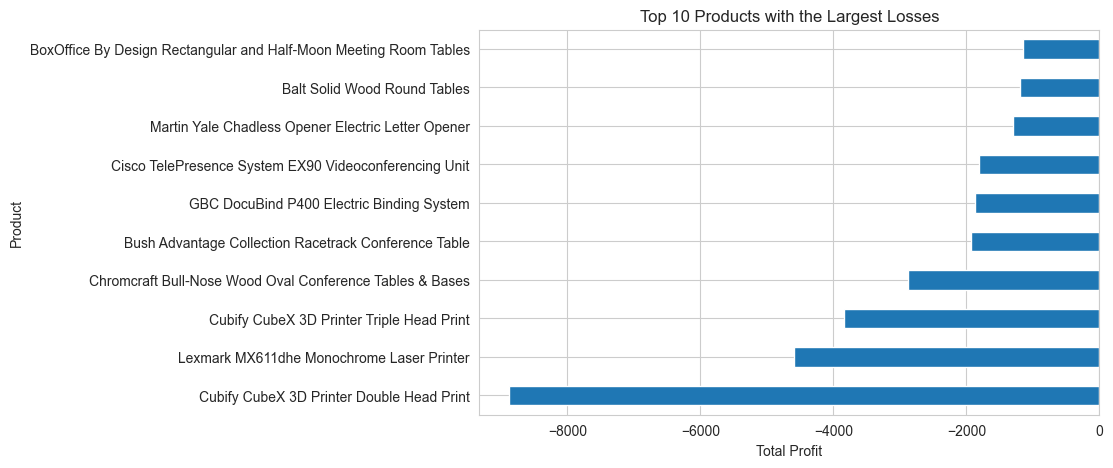

In [36]:
worst_products.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Products with the Largest Losses")
plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.show()

### Insight

Several individual products generate substantial losses.

The Cubify CubeX 3D Printer Double Head Print stands out as the product with the largest total loss, significantly below the rest. Other items such as the Lexmark MX611dhe Monochrome Laser Printer and the Cubify CubeX 3D Printer Triple Head Print also generate notable negative profit.

A number of conference tables also appear among the loss-generating products, suggesting that some furniture items may be particularly unprofitable.

## Profit Margin of Top Selling Products

### Business Question

Among the top-selling products, which ones generate the highest and lowest profit margins?

In [37]:
product_performance = (
    df.groupby("Product Name")[["Sales","Profit"]]
    .sum()
)

top_sales_products = (
    product_performance
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_sales_products["Profit Margin"] = (
    top_sales_products["Profit"] / top_sales_products["Sales"]
)

top_sales_products.sort_values("Profit Margin")

,Sales,Profit,Profit Margin
Product Name,,,
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,-1.045455e-01
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,-8.000000e-02
High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02,-1.538462e-02
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,2.599082e-18
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,4.000000e-02
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,1.126697e-01
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,2.228571e-01
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,2.824074e-01
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,3.707006e-01


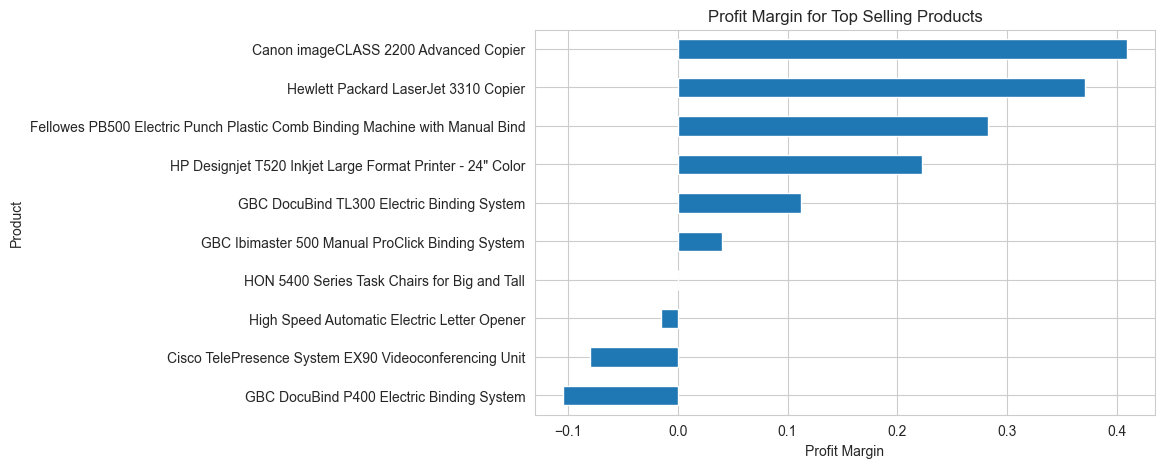

In [38]:
top_sales_products.sort_values("Profit Margin")["Profit Margin"].plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Profit Margin for Top Selling Products")
plt.xlabel("Profit Margin")
plt.ylabel("Product")

plt.show()

### Insight

Profit margins vary significantly among the top-selling products.

Some products, such as the Canon imageCLASS 2200 Advanced Copier and the HP LaserJet 3310 Copier, combine high sales with strong profit margins. In contrast, other popular products generate very low or even negative margins. For example, the Cisco TelePresence System EX90 Videoconferencing Unit and the GBC DocuBind P400 Electric Binding System appear among the top-selling products but produce negative profit margins.

This suggests that high sales volume does not necessarily translate into profitability for all products.

## Share of Products Generating Losses

### Business Question

What proportion of products generate negative total profit?

In [39]:
product_profit = df.groupby("Product Name")["Profit"].sum()

loss_products = (product_profit < 0).sum()
profit_products = (product_profit > 0).sum()

loss_products, profit_products

(np.int64(301), np.int64(1546))

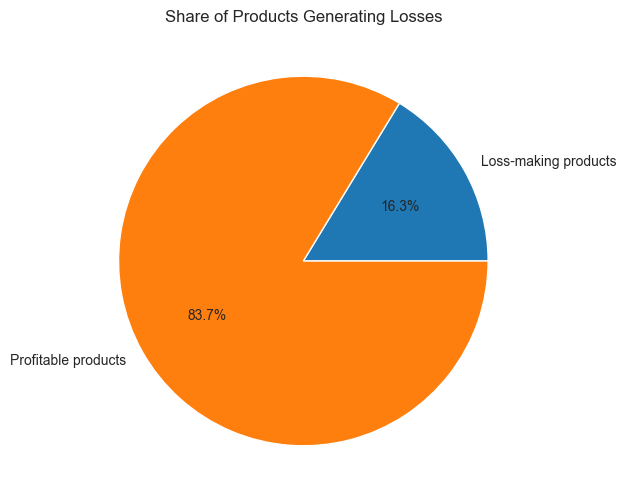

In [40]:
plt.figure(figsize=(6,6))

plt.pie(
    [loss_products, profit_products],
    labels=["Loss-making products", "Profitable products"],
    autopct="%1.1f%%"
)

plt.title("Share of Products Generating Losses")

plt.show()

### Insight

Most products generate positive total profit.

Approximately 83.7% of products are profitable, while about 16.3% generate overall losses. Although loss-making products represent a minority, the previous analysis showed that some of them can still generate substantial negative profit, which may have a meaningful impact on overall profitability.

## Key Takeaways

This analysis reveals that product performance varies significantly across the catalog. A small number of products drive a large portion of both sales and profit, while some popular products generate very low or even negative margins. Additionally, a non-trivial share of products contribute negatively to profitability.

These findings suggest that product-level pricing, discounting, or cost structures may require closer examination to improve overall profitability.